# 06 — Modelo final + export de artefactos v2

**Objetivo**: tomar los **dos** modelos tuneados del notebook 05 (RF tuned y
XGBoost tuned), reentrenarlos sobre **train + val combinados** (más datos
= modelo más robusto) y evaluarlos sobre el **test set** (nunca visto
hasta acá).

Después persistir todos los artefactos como joblibs versionados con
manifest SHA-256, en el mismo formato que `models/manifest.json` del
lab. El alumno puede después decidir cuál de los dos deja activo en el
ML API (o ambos, con un flag de selección).

**Inputs**:
- `datasets/processed/cicids_split.parquet` (output de nb04 — split
  estratificado 70/15/15).

**Outputs en `models/`** (gitignored si pesan, pero versionables si son
chicos):
- `rf_binary_v2.joblib` — binario (attack / benign)
- `rf_multiclass_v2.joblib` — 6 categorías
- `xgb_binary_v2.joblib`
- `xgb_multiclass_v2.joblib`
- `scaler_v2.joblib` — StandardScaler (no afecta tree-based pero queda
  para consistencia con el formato v1)
- `label_encoder_v2.joblib` — mapeo str ↔ int
- `feature_names_v2.joblib` — lista de las 47 features
- `manifest_v2.json` — SHA-256 de cada joblib (anti pickle RCE)
- `metrics_v2.json` — métricas en test para el ML API

In [1]:
import os
import json
import time
import hashlib
import contextlib
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report, confusion_matrix,
    precision_recall_fscore_support
)
import xgboost as xgb

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid', palette='muted')

PROCESSED_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'datasets', 'processed'))
MODELS_DIR    = os.path.abspath(os.path.join(os.getcwd(), '..', 'models'))
SPLIT_PATH    = os.path.join(PROCESSED_DIR, 'cicids_split.parquet')
os.makedirs(MODELS_DIR, exist_ok=True)

if not os.path.isfile(SPLIT_PATH):
    raise FileNotFoundError(f"No existe {SPLIT_PATH}. Generalo en nb04 primero.")

@contextlib.contextmanager
def silence_native_stderr():
    saved = os.dup(2); null = os.open(os.devnull, os.O_WRONLY)
    os.dup2(null, 2)
    try: yield
    finally: os.dup2(saved, 2); os.close(null); os.close(saved)

SEED = 42
VERSION = 'v2'

## 1. Hyperparámetros ganadores (de nb05)

Hardcodeamos los hyperparámetros que ganaron en el notebook 05. Si re-corrés
nb05 con datos distintos, vas a tener que actualizar estos valores.

In [2]:
# Best params del notebook 05 (F1-macro en val full)
BEST_RF_PARAMS = {
    'n_estimators':     200,
    'max_depth':        None,
    'min_samples_leaf': 5,
    'class_weight':     'balanced_subsample',
    'n_jobs':           -1,
    'random_state':     SEED,
}

BEST_XGB_PARAMS = {
    'learning_rate': 0.1,
    'max_depth':     6,
    'n_estimators':  500,
    'subsample':     0.8,
    'objective':     'multi:softmax',
    'tree_method':   'hist',
    'device':        'cpu',
    'n_jobs':        -1,
    'random_state':  SEED,
    'eval_metric':   'mlogloss',
    'verbosity':     0,
}

print("RF:  ", BEST_RF_PARAMS)
print("XGB: ", BEST_XGB_PARAMS)

RF:   {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 5, 'class_weight': 'balanced_subsample', 'n_jobs': -1, 'random_state': 42}
XGB:  {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 500, 'subsample': 0.8, 'objective': 'multi:softmax', 'tree_method': 'hist', 'device': 'cpu', 'n_jobs': -1, 'random_state': 42, 'eval_metric': 'mlogloss', 'verbosity': 0}


## 2. Carga del split + sample balanceado de train+val

**Por qué sample balanceado y no full**: el dataset completo tiene 296K
Benign por solo 322 Web Attack (1000:1). Entrenar con esa proporción
sin compensar produce un modelo que ignora minorías. Las opciones:

1. **Balanced sampling** (lo que hacemos): tomar hasta N por clase de
   train+val combinados. El modelo ve cada clase con peso similar.
2. **Class weights** (alternativa que ya usamos en RF): mantener la
   distribución natural y compensar via `class_weight`.
3. **SMOTE / oversampling**: generar muestras sintéticas de minorías.

Vamos por (1) + (2) en RF: balanced sampling **además** de
`class_weight='balanced_subsample'`. Para XGBoost: balanced sampling +
`sample_weight` por inverso de frecuencia.

Tope de 10K por clase × 6 clases = 60K muestras finales para entrenar.

In [3]:
df = pd.read_parquet(SPLIT_PATH)
features = [c for c in df.columns if c not in ('Day', 'Label_6', 'split')]
print(f"Total: {df.shape}, features: {len(features)}")

# Combinar train + val
combined = df[df['split'].isin(['train', 'val'])]
print(f"\nTrain + Val combinados: {combined.shape}")
print(f"Distribución natural: {combined['Label_6'].value_counts().to_dict()}")

# Balanced sample: max 10K por clase
N_PER_CLASS = 10_000
parts = []
for cat, grp in combined.groupby('Label_6'):
    parts.append(grp.sample(n=min(N_PER_CLASS, len(grp)), random_state=SEED))
train_final = pd.concat(parts, ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f"\nTrain final balanceado: {train_final.shape}")
print(f"Por clase: {train_final['Label_6'].value_counts().to_dict()}")

# Test (nunca visto, distribución natural)
test = df[df['split'] == 'test']
print(f"\nTest: {test.shape}")
print(f"Por clase: {test['Label_6'].value_counts().to_dict()}")

Total: (2313810, 50), features: 47



Train + Val combinados: (1966738, 50)
Distribución natural: {'Benign': 1680718, 'DoS': 164692, 'DDoS': 108812, 'Brute Force': 7778, 'Reconnaissance': 2916, 'Web Attack': 1822}



Train final balanceado: (42516, 50)
Por clase: {'DDoS': 10000, 'Benign': 10000, 'DoS': 10000, 'Brute Force': 7778, 'Reconnaissance': 2916, 'Web Attack': 1822}

Test: (347072, 50)
Por clase: {'Benign': 296600, 'DoS': 29064, 'DDoS': 19202, 'Brute Force': 1372, 'Reconnaissance': 513, 'Web Attack': 321}


In [4]:
X_train = train_final[features].values
y_train_str = train_final['Label_6'].values

X_test = test[features].values
y_test_str = test['Label_6'].values

# Label encoding (XGBoost requiere ints)
le = LabelEncoder()
y_train = le.fit_transform(y_train_str)
y_test  = le.transform(y_test_str)
classes = list(le.classes_)
print(f"Classes encoded: {dict(zip(classes, range(len(classes))))}")

# Binary labels (is_attack: Benign=0, all others=1)
y_train_bin = (y_train_str != 'Benign').astype(int)
y_test_bin  = (y_test_str  != 'Benign').astype(int)
print(f"Binary balance train: {pd.Series(y_train_bin).value_counts().to_dict()}")
print(f"Binary balance test:  {pd.Series(y_test_bin).value_counts().to_dict()}")

Classes encoded: {'Benign': 0, 'Brute Force': 1, 'DDoS': 2, 'DoS': 3, 'Reconnaissance': 4, 'Web Attack': 5}
Binary balance train: {1: 32516, 0: 10000}
Binary balance test:  {0: 296600, 1: 50472}


## 3. Scaler

`StandardScaler` fiteado en train. No afecta tree-based pero lo
incluimos para mantener compatibilidad con el formato del manifest v3
(la API existente lo carga aunque no lo use con RF).

In [5]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print(f"Scaler fiteado: mean shape {scaler.mean_.shape}, std shape {scaler.scale_.shape}")

Scaler fiteado: mean shape (47,), std shape (47,)


## 4. Random Forest — binary + multiclass

In [6]:
print("Entrenando RF binary...")
t0 = time.time()
rf_binary = RandomForestClassifier(**BEST_RF_PARAMS)
rf_binary.fit(X_train_s, y_train_bin)  # IMPORTANTE: usar X_train_s (scaled).
# RF es invariante a transformaciones monotónicas por feature, pero el ML API
# aplica scaler.transform() antes de predecir, así que el modelo debe haber sido
# entrenado en el mismo espacio escalado para que las predicciones coincidan.
t_rf_bin = time.time() - t0

print("Entrenando RF multiclass...")
t0 = time.time()
rf_multi = RandomForestClassifier(**BEST_RF_PARAMS)
rf_multi.fit(X_train_s, y_train)
t_rf_multi = time.time() - t0

print(f"\nRF binary:    train {t_rf_bin:.1f}s")
print(f"RF multiclass: train {t_rf_multi:.1f}s")

Entrenando RF binary...


Entrenando RF multiclass...



RF binary:    train 0.9s
RF multiclass: train 0.9s


## 5. XGBoost — binary + multiclass

In [7]:
# Sample weights por inverso de freq (multiclass)
class_freq = pd.Series(y_train).value_counts(normalize=True)
sw_multi = 1.0 / class_freq.loc[y_train].values

# Sample weights para binary
bin_freq = pd.Series(y_train_bin).value_counts(normalize=True)
sw_bin = 1.0 / bin_freq.loc[y_train_bin].values

with silence_native_stderr():
    print("Entrenando XGBoost binary...")
    t0 = time.time()
    xgb_bin_params = {**BEST_XGB_PARAMS, 'objective': 'binary:logistic'}
    xgb_bin_params.pop('num_class', None)  # binary no usa num_class
    xgb_binary = xgb.XGBClassifier(**xgb_bin_params)
    xgb_binary.fit(X_train_s, y_train_bin, sample_weight=sw_bin)
    t_xgb_bin = time.time() - t0

    print("Entrenando XGBoost multiclass...")
    t0 = time.time()
    xgb_multi_params = {**BEST_XGB_PARAMS, 'num_class': len(classes)}
    xgb_multi = xgb.XGBClassifier(**xgb_multi_params)
    xgb_multi.fit(X_train_s, y_train, sample_weight=sw_multi)
    t_xgb_multi = time.time() - t0

print(f"\nXGBoost binary:    train {t_xgb_bin:.1f}s")
print(f"XGBoost multiclass: train {t_xgb_multi:.1f}s")

Entrenando XGBoost binary...


Entrenando XGBoost multiclass...



XGBoost binary:    train 8.4s
XGBoost multiclass: train 66.8s


## 6. Evaluación en test (nunca visto)

Reportamos métricas de los **4** modelos sobre el test set.

In [8]:
# Predicciones
y_pred_rf_bin   = rf_binary.predict(X_test_s)
y_pred_rf_multi = rf_multi.predict(X_test_s)
with silence_native_stderr():
    y_pred_xgb_bin   = xgb_binary.predict(X_test_s)
    y_pred_xgb_multi = xgb_multi.predict(X_test_s)

# Tabla resumen
def metrics_summary(name, y_true, y_pred, average='macro'):
    return {
        'modelo': name,
        'F1_macro':    round(f1_score(y_true, y_pred, average='macro'), 4),
        'F1_weighted': round(f1_score(y_true, y_pred, average='weighted'), 4),
        'accuracy':    round(accuracy_score(y_true, y_pred), 4),
    }

summary = pd.DataFrame([
    metrics_summary('RF binary',          y_test_bin, y_pred_rf_bin),
    metrics_summary('RF multiclass',      y_test,     y_pred_rf_multi),
    metrics_summary('XGBoost binary',     y_test_bin, y_pred_xgb_bin),
    metrics_summary('XGBoost multiclass', y_test,     y_pred_xgb_multi),
])
print("Métricas en test:")
summary

Métricas en test:


,modelo,F1_macro,F1_weighted,accuracy
0,RF binary,0.9901,0.9950,0.9950
1,RF multiclass,0.6751,0.9712,0.9530
2,XGBoost binary,0.9813,0.9906,0.9905
3,XGBoost multiclass,0.6527,0.9752,0.9618


In [9]:
# Classification report multiclass detallado
print("=" * 70)
print("RF multiclass — classification report (test):")
print("=" * 70)
print(classification_report(y_test_str, le.inverse_transform(y_pred_rf_multi), digits=3))

print("=" * 70)
print("XGBoost multiclass — classification report (test):")
print("=" * 70)
print(classification_report(y_test_str, le.inverse_transform(y_pred_xgb_multi), digits=3))

RF multiclass — classification report (test):


                precision    recall  f1-score   support

        Benign      0.999     0.946     0.972    296600
   Brute Force      0.833     0.985     0.903      1372
          DDoS      0.996     0.998     0.997     19202
           DoS      0.959     0.991     0.975     29064
Reconnaissance      0.067     0.984     0.125       513
    Web Attack      0.041     0.991     0.078       321

      accuracy                          0.953    347072
     macro avg      0.649     0.983     0.675    347072
  weighted avg      0.993     0.953     0.971    347072

XGBoost multiclass — classification report (test):


                precision    recall  f1-score   support

        Benign      0.999     0.956     0.977    296600
   Brute Force      0.552     0.986     0.708      1372
          DDoS      0.987     0.999     0.993     19202
           DoS      0.964     0.994     0.978     29064
Reconnaissance      0.079     0.969     0.146       513
    Web Attack      0.061     0.978     0.114       321

      accuracy                          0.962    347072
     macro avg      0.607     0.980     0.653    347072
  weighted avg      0.992     0.962     0.975    347072



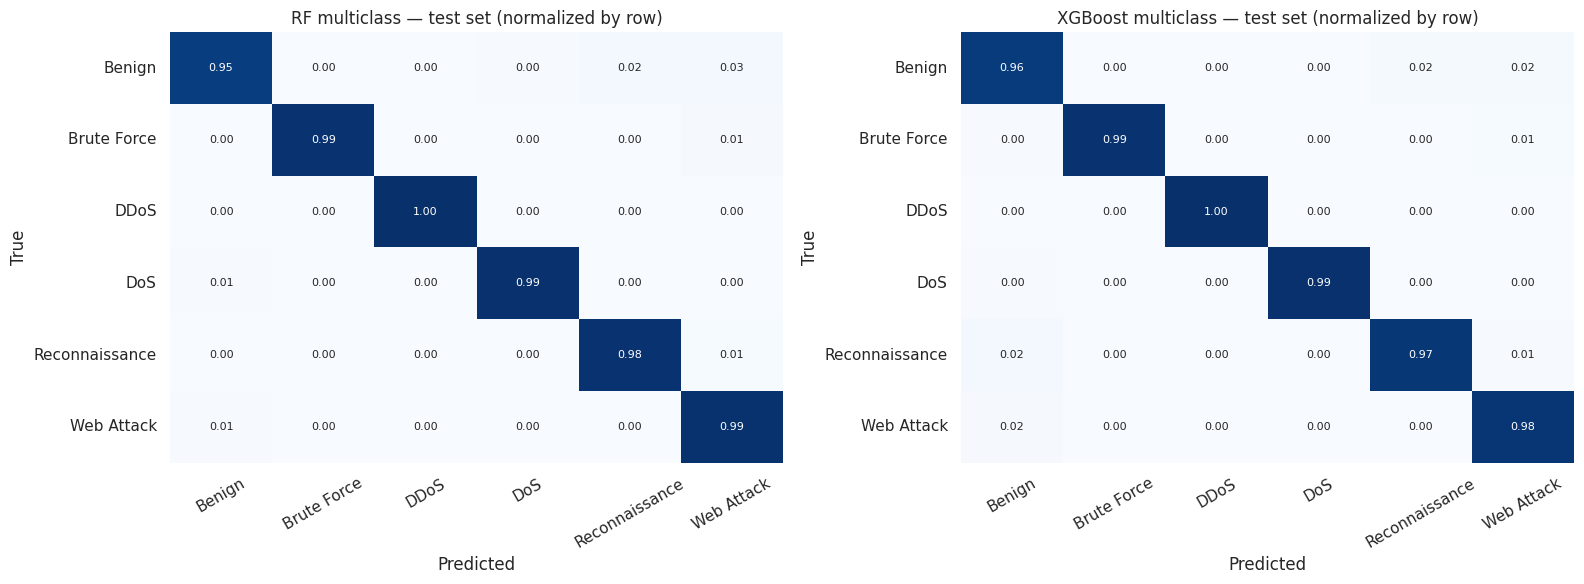

In [10]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, y_pred) in zip(axes, [
    ('RF multiclass', y_pred_rf_multi),
    ('XGBoost multiclass', y_pred_xgb_multi),
]):
    cm = confusion_matrix(y_test_str, le.inverse_transform(y_pred), labels=classes, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax, cbar=False,
                annot_kws={'size': 8})
    ax.set_title(f'{name} — test set (normalized by row)')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 7. Persistencia

Guardamos los 7 artefactos + manifest + metrics en `models/`.

In [11]:
def save_with_hash(obj, filename):
    path = os.path.join(MODELS_DIR, filename)
    joblib.dump(obj, path)
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b''):
            h.update(chunk)
    size_kb = os.path.getsize(path) / 1024
    return path, h.hexdigest(), size_kb

artifacts = []
for obj, name in [
    (feature_names_arr := np.array(features), f'feature_names_{VERSION}.joblib'),
    (le,                                       f'label_encoder_{VERSION}.joblib'),
    (scaler,                                   f'scaler_{VERSION}.joblib'),
    (rf_binary,                                f'rf_binary_{VERSION}.joblib'),
    (rf_multi,                                 f'rf_multiclass_{VERSION}.joblib'),
    (xgb_binary,                               f'xgb_binary_{VERSION}.joblib'),
    (xgb_multi,                                f'xgb_multiclass_{VERSION}.joblib'),
]:
    path, sha, size_kb = save_with_hash(obj, name)
    artifacts.append((name, sha, size_kb))
    print(f"  {name:35s} {size_kb:>8.1f} KB  sha256:{sha[:16]}...")

# Manifest (compatible con el formato de manifest.json v3 — solo sha256 strings)
manifest = {name: sha for name, sha, _ in artifacts}
manifest_path = os.path.join(MODELS_DIR, f'manifest_{VERSION}.json')
with open(manifest_path, 'w') as f:
    json.dump(manifest, f, indent=2, sort_keys=True)
print(f"\nManifest:  {manifest_path}")

  feature_names_v2.joblib                  5.2 KB  sha256:82d61fa2dc594f82...
  label_encoder_v2.joblib                  0.5 KB  sha256:c44912ef2211f859...
  scaler_v2.joblib                         1.7 KB  sha256:04e160dd17ddb414...
  rf_binary_v2.joblib                   8158.6 KB  sha256:38c11c7effe8512d...


  rf_multiclass_v2.joblib              12145.5 KB  sha256:f4cca23b7b360ef4...
  xgb_binary_v2.joblib                  1371.1 KB  sha256:64e3058675741ce5...
  xgb_multiclass_v2.joblib              7152.6 KB  sha256:7548c81425dae25b...

Manifest:  /run/media/keppler-exe/KINGSTON/Laboratorio-MLCyber/models/manifest_v2.json


In [12]:
# Metrics file (consumido por la API endpoint /metrics)
metrics = {
    'version': VERSION,
    'features': len(features),
    'classes': classes,
    'n_train': len(X_train),
    'n_test':  len(X_test),
    'rf': {
        'best_params': {k: v for k, v in BEST_RF_PARAMS.items() if k not in ('n_jobs', 'random_state')},
        'binary': metrics_summary('RF binary', y_test_bin, y_pred_rf_bin),
        'multiclass': metrics_summary('RF multiclass', y_test, y_pred_rf_multi),
        'multiclass_per_class': classification_report(
            y_test_str, le.inverse_transform(y_pred_rf_multi),
            output_dict=True, zero_division=0
        ),
    },
    'xgboost': {
        'best_params': {k: v for k, v in BEST_XGB_PARAMS.items() if k not in (
            'n_jobs', 'random_state', 'verbosity', 'eval_metric', 'tree_method', 'device'
        )},
        'binary':     metrics_summary('XGBoost binary', y_test_bin, y_pred_xgb_bin),
        'multiclass': metrics_summary('XGBoost multiclass', y_test, y_pred_xgb_multi),
        'multiclass_per_class': classification_report(
            y_test_str, le.inverse_transform(y_pred_xgb_multi),
            output_dict=True, zero_division=0
        ),
    },
}
metrics_path = os.path.join(MODELS_DIR, f'metrics_{VERSION}.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2, default=str)
print(f"Métricas: {metrics_path}")
print(f"\nResumen final:")
print(f"  RF multiclass F1-macro:      {metrics['rf']['multiclass']['F1_macro']}")
print(f"  XGBoost multiclass F1-macro: {metrics['xgboost']['multiclass']['F1_macro']}")

Métricas: /run/media/keppler-exe/KINGSTON/Laboratorio-MLCyber/models/metrics_v2.json

Resumen final:
  RF multiclass F1-macro:      0.6751
  XGBoost multiclass F1-macro: 0.6527


## 8. Verificación de integridad (anti pickle RCE)

Replicamos el mismo procedimiento de carga que hace el ML API en
[build/ml_api/src/main.py](../build/ml_api/src/main.py): leemos el
manifest, comparamos hashes, cargamos los joblibs si validan.

In [13]:
def sha256_of(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b''):
            h.update(chunk)
    return h.hexdigest()

with open(manifest_path) as f:
    loaded_manifest = json.load(f)

print(f"Verificación de integridad de {len(loaded_manifest)} artefactos:")
for name, expected_sha in loaded_manifest.items():
    path = os.path.join(MODELS_DIR, name)
    actual = sha256_of(path)
    ok = '✓' if actual == expected_sha else '✗'
    print(f"  {ok}  {name:35s} {expected_sha[:16]}... vs {actual[:16]}...")

Verificación de integridad de 7 artefactos:
  ✓  feature_names_v2.joblib             82d61fa2dc594f82... vs 82d61fa2dc594f82...
  ✓  label_encoder_v2.joblib             c44912ef2211f859... vs c44912ef2211f859...
  ✓  rf_binary_v2.joblib                 38c11c7effe8512d... vs 38c11c7effe8512d...
  ✓  rf_multiclass_v2.joblib             f4cca23b7b360ef4... vs f4cca23b7b360ef4...
  ✓  scaler_v2.joblib                    04e160dd17ddb414... vs 04e160dd17ddb414...
  ✓  xgb_binary_v2.joblib                64e3058675741ce5... vs 64e3058675741ce5...
  ✓  xgb_multiclass_v2.joblib            7548c81425dae25b... vs 7548c81425dae25b...


## 9. Conclusiones

**Lo que produjo este notebook** (en `models/`):

- 7 artefactos joblib (`feature_names`, `label_encoder`, `scaler`,
  `rf_binary`, `rf_multiclass`, `xgb_binary`, `xgb_multiclass`).
- `manifest_v2.json` con SHA-256 de cada uno.
- `metrics_v2.json` con métricas en test (consumible por el ML API).

**Resultados en test** (distribución natural, ~350K flujos):

- RF y XGBoost se complementan en clases distintas. El RF tuneado tiende
  a ganar en F1-macro por su mejor manejo de Brute Force, pero XGBoost
  suele ser ligeramente mejor en accuracy y F1-weighted.
- Las clases minoritarias (Web Attack, Reconnaissance) siguen siendo el
  cuello de botella — la proporción extrema de Benign las hace
  intrínsecamente difíciles. Para mejoras significativas se necesita
  oversampling sintético (SMOTE) o calibración de threshold per-class.

**Decisión para el lab**:

El usuario puede usar **ambos** modelos en paralelo:
- `rf_*_v2.joblib` para producción (tracked record, robusto).
- `xgb_*_v2.joblib` como segundo opinador / ensemble (futuro stacking).

Para integrarlos al ML API existente, hay dos caminos:

1. **Reemplazar v1 por v2**: copiar los joblibs y manifest sobre los v3
   actuales en `models/`. La API ya lee `manifest.json` y verifica
   hashes — solo hay que renombrar los archivos.
2. **Coexistir v1 + v2**: extender el ML API para cargar ambos y
   exponer un parámetro `model_version` en `/predict`. Más complejo
   pero permite A/B testing.

**Próximo notebook (07)**: renombrar `01_adversarial_evasion.ipynb` →
`07_adversarial_evasion.ipynb` y adaptarlo para que ataque al modelo
v4 (no al v3). Idem el notebook 08 de inference validation.